# Comparative Analysis of Machine Learning Algorithms for Fake News Detection
### Final Analysis Notebook - Bias Correction, Baseline, Feature Fusion, Ensemble, Validation
Run every cell in order, top to bottom, using Shift+Enter.

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn scipy

You should consider upgrading via the 'c:\Users\ayush\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


## STEP 1: Import Basic Data & Visualization Libraries
pandas loads/organizes CSV data, numpy handles math, matplotlib/seaborn draw charts, and re/string/os are Python's built-in text and file tools.

In [2]:
# pandas - loads and organizes CSV data into a table
import pandas as pd

# numpy - handles numerical/math operations
import numpy as np

# matplotlib and seaborn - draw charts and graphs for thesis figures
import matplotlib.pyplot as plt
import seaborn as sns

# re, string, os - built into Python, no installation needed
import re
import string
import os

sns.set(style="darkgrid")
print("Step 1 complete: pandas, numpy, matplotlib, and seaborn all imported successfully")

Step 1 complete: pandas, numpy, matplotlib, and seaborn all imported successfully


## STEP 2: Import Machine Learning Tools (scikit-learn)
These build and train our 5 classifiers, split data, build the ensemble, and measure performance (accuracy, F1, cross-validation, error metrics).

In [3]:
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, log_loss, brier_score_loss, mean_squared_error
)

print("Step 2 complete: all scikit-learn machine learning tools imported successfully")

Step 2 complete: all scikit-learn machine learning tools imported successfully


## STEP 3: Load the Dataset
Loads Fake.csv and True.csv, labels each article (0=Fake, 1=Real), combines them, and shuffles so fake/real articles are mixed together.

In [4]:
# check if Fake.csv and True.csv exist inside the data folder before trying to load them
if os.path.exists("data/Fake.csv") and os.path.exists("data/True.csv"):

    # load both CSV files into pandas tables
    fake_df = pd.read_csv("data/Fake.csv")
    true_df = pd.read_csv("data/True.csv")

    # add a new column called "label" - 0 means fake, 1 means real
    fake_df["label"] =0
    true_df["label"] = 1

    # print how many articles are in each file, as (rows, columns)
    print("Fake news articles:", fake_df.shape)
    print("Real news articles:", true_df.shape)

    # stack the fake and real articles on top of each other into one big table
    df = pd.concat([fake_df, true_df], axis=0)

    # combine the title and the full text into one single column called "content"
    df["content"] = df["title"].astype(str) + " " + df["text"].astype(str)

    # keep only the columns we actually need: the text content and its label
    df = df[["content", "label"]]

else:
    # if the files aren't found, stop here with a clear error message
    raise FileNotFoundError("Fake.csv and True.csv not found inside the data/ folder.")

# shuffle all the rows randomly so fake and real articles are mixed together
# random_state=42 makes the shuffle reproducible (same shuffle every time we run this)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# print the final combined dataset size
print("\nCombined dataset shape:", df.shape)

# print how many fake (0) vs real (1) articles we have in total
print(df["label"].value_counts())

# show the first 5 rows so we can see what the data actually looks like
df.head()

Fake news articles: (23481, 5)
Real news articles: (21417, 5)

Combined dataset shape: (44898, 2)
label
0    23481
1    21417
Name: count, dtype: int64


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


## STEP 4: Visualize the Class Distribution (Figure 3.2)

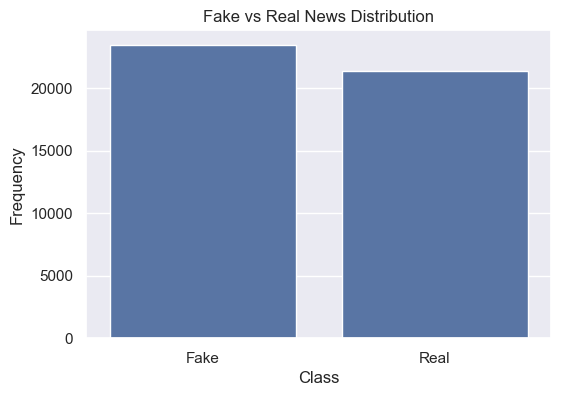

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.xticks([0,1], ["Fake","Real"])
plt.title("Fake vs Real News Distribution")
plt.xlabel("Class"); plt.ylabel("Frequency")
plt.show()

## STEP 5: Remove Source Artifacts, Then Clean the Text
Before general cleaning, publisher-identifying signals like "WASHINGTON (Reuters) -" are stripped out first. Without this, models can achieve artificially high accuracy by learning to recognize the SOURCE'S formatting rather than genuinely detecting deceptive content - this is the bias-aware preprocessing part of the proposed novel method.

After artifact removal, the text is cleaned as usual: lowercased, with URLs, numbers, and punctuation removed.

In [6]:
# STEP 5a: Remove source/publisher artifacts BEFORE any other cleaning
def remove_source_artifacts(text):
    text = str(text)
    # remove patterns like "WASHINGTON (Reuters) -" or "NEW YORK (Reuters) --"
    text = re.sub(r"\b[A-Z][A-Za-z\s]*\(Reuters\)\s*-+\s*", "", text)
    text = re.sub(r"\(Reuters\)", "", text)
    # also handle Associated Press (AP) style datelines, just in case
    text = re.sub(r"\b[A-Z][A-Za-z\s]*\(AP\)\s*-+\s*", "", text)
    text = re.sub(r"\(AP\)", "", text)
    return text

df["content_debiased"] = df["content"].apply(remove_source_artifacts)

reuters_count = df["content"].str.contains(r"\(Reuters\)", regex=True).sum()
print(f"Articles that originally contained '(Reuters)': {reuters_count} out of {len(df)}")

# STEP 5b: Clean the debiased text (lowercase, remove URLs/numbers/punctuation)
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_content"] = df["content_debiased"].apply(clean_text)
print("\nSample cleaned (debiased) text:")
print(df["clean_content"].iloc[0][:300])

Articles that originally contained '(Reuters)': 21256 out of 44898

Sample cleaned (debiased) text:
ben stein calls out th circuit court committed a ‘coup d’état’ against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge


---
# ANALYSIS 1: BASELINE (TF-IDF Word Features Only)
This matches the standard approach used across the literature review - plain word-frequency features, no enhancements yet.

## STEP 6: Convert Text to Numbers (TF-IDF)
TF-IDF scores each word by how important it is to one article versus the whole dataset, turning text into numbers the models can learn from.

In [7]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X = tfidf.fit_transform(df["clean_content"])
y = df["label"]
print("TF-IDF feature matrix shape:", X.shape)

TF-IDF feature matrix shape: (44898, 5000)


## STEP 8: Train & Evaluate 5 Baseline Classifiers

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": LinearSVC(max_iter=2000),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
}

baseline_results = {}
baseline_conf_matrices = {}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    f1 = f1_score(y_test, preds) * 100
    prec = precision_score(y_test, preds) * 100
    rec = recall_score(y_test, preds) * 100
    baseline_results[name] = {"Accuracy": acc, "F1 Score": f1, "Precision": prec, "Recall": rec}
    baseline_conf_matrices[name] = confusion_matrix(y_test, preds)
    print(f"  {name} -> Accuracy: {acc:.2f}%  F1: {f1:.2f}%  Precision: {prec:.2f}%  Recall: {rec:.2f}%")

baseline_df = pd.DataFrame(baseline_results).T.round(2)
print("\n=== BASELINE RESULTS (Table 4.1) ===")
baseline_df

Training Logistic Regression ...
  Logistic Regression -> Accuracy: 97.88%  F1: 97.78%  Precision: 97.34%  Recall: 98.22%
Training Naive Bayes ...
  Naive Bayes -> Accuracy: 92.64%  F1: 92.20%  Precision: 92.89%  Recall: 91.52%
Training Random Forest ...
  Random Forest -> Accuracy: 98.46%  F1: 98.38%  Precision: 98.39%  Recall: 98.38%
Training SVM ...
  SVM -> Accuracy: 98.67%  F1: 98.60%  Precision: 98.47%  Recall: 98.74%
Training Passive Aggressive ...
  Passive Aggressive -> Accuracy: 98.45%  F1: 98.37%  Precision: 98.33%  Recall: 98.41%

=== BASELINE RESULTS (Table 4.1) ===


,Accuracy,F1 Score,Precision,Recall
Logistic Regression,97.88,97.78,97.34,98.22
Naive Bayes,92.64,92.20,92.89,91.52
Random Forest,98.46,98.38,98.39,98.38
SVM,98.67,98.60,98.47,98.74
Passive Aggressive,98.45,98.37,98.33,98.41


### STEP 8a: Cross-Validation & Overfitting Check - Baseline
Checks whether the baseline results above are reliable (5-fold cross-validation) and whether any model is overfitting (memorizing training data) or underfitting (too simple to learn the pattern at all).

In [10]:
cv_models_baseline = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3),
    "Passive Aggressive": CalibratedClassifierCV(
        PassiveAggressiveClassifier(max_iter=1000, random_state=42), cv=3
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("=== Cross-Validation: BASELINE ===")
cv_results_baseline = {}
for name, model in cv_models_baseline.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_results_baseline[name] = {"CV Mean Acc (%)": round(scores.mean()*100,2),
                                  "CV Std (%)": round(scores.std()*100,2)}
    print(f"  {name}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

print("\n=== Overfitting/Underfitting Check: BASELINE ===")
fit_results_baseline = {}
for name, model in cv_models_baseline.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
    test_acc = accuracy_score(y_test, model.predict(X_test)) * 100
    gap = round(train_acc - test_acc, 2)
    if gap > 5:
        verdict = "Possible OVERFITTING"
    elif train_acc < 80 and test_acc < 80:
        verdict = "Possible UNDERFITTING"
    else:
        verdict = "Good fit"
    fit_results_baseline[name] = {"Train (%)": round(train_acc,2), "Test (%)": round(test_acc,2),
                                   "Gap (%)": gap, "Verdict": verdict}
    print(f"  {name}: Train={train_acc:.2f}% Test={test_acc:.2f}% Gap={gap}% -> {verdict}")

=== Cross-Validation: BASELINE ===
  Logistic Regression: 97.96% (+/- 0.13%)
  Naive Bayes: 92.59% (+/- 0.14%)
  Random Forest: 98.46% (+/- 0.08%)
  SVM: 98.70% (+/- 0.12%)
  Passive Aggressive: 98.71% (+/- 0.09%)

=== Overfitting/Underfitting Check: BASELINE ===
  Logistic Regression: Train=98.58% Test=97.88% Gap=0.7% -> Good fit
  Naive Bayes: Train=92.86% Test=92.64% Gap=0.22% -> Good fit
  Random Forest: Train=100.00% Test=98.46% Gap=1.54% -> Good fit
  SVM: Train=99.63% Test=98.63% Gap=1.0% -> Good fit
  Passive Aggressive: Train=100.00% Test=98.64% Gap=1.36% -> Good fit


## STEP 8B: Display Baseline Overfitting Results

The training accuracy, testing accuracy, train-test accuracy gap, and corresponding fit assessment of the baseline TF-IDF models are presented below.

The results are used to examine whether the baseline models maintain similar performance on the training and unseen testing data.

In [11]:
# ============================================================
# STEP 8B: DISPLAY BASELINE OVERFITTING RESULTS
# ============================================================

# Convert the existing baseline overfitting results
# into a DataFrame for clear presentation.
baseline_overfit_df = pd.DataFrame(fit_results_baseline).T

# Display the results
display(baseline_overfit_df)

,Train (%),Test (%),Gap (%),Verdict
Logistic Regression,98.58,97.88,0.7,Good fit
Naive Bayes,92.86,92.64,0.22,Good fit
Random Forest,100.0,98.46,1.54,Good fit
SVM,99.63,98.63,1.0,Good fit
Passive Aggressive,100.0,98.64,1.36,Good fit


## STEP 8C: Training vs Testing Accuracy of Baseline TF-IDF Models

The following figure compares the training and testing accuracy of the baseline TF-IDF models.

A relatively small difference between training and testing accuracy indicates that the model performs consistently on seen and unseen data. A larger difference may indicate possible overfitting.

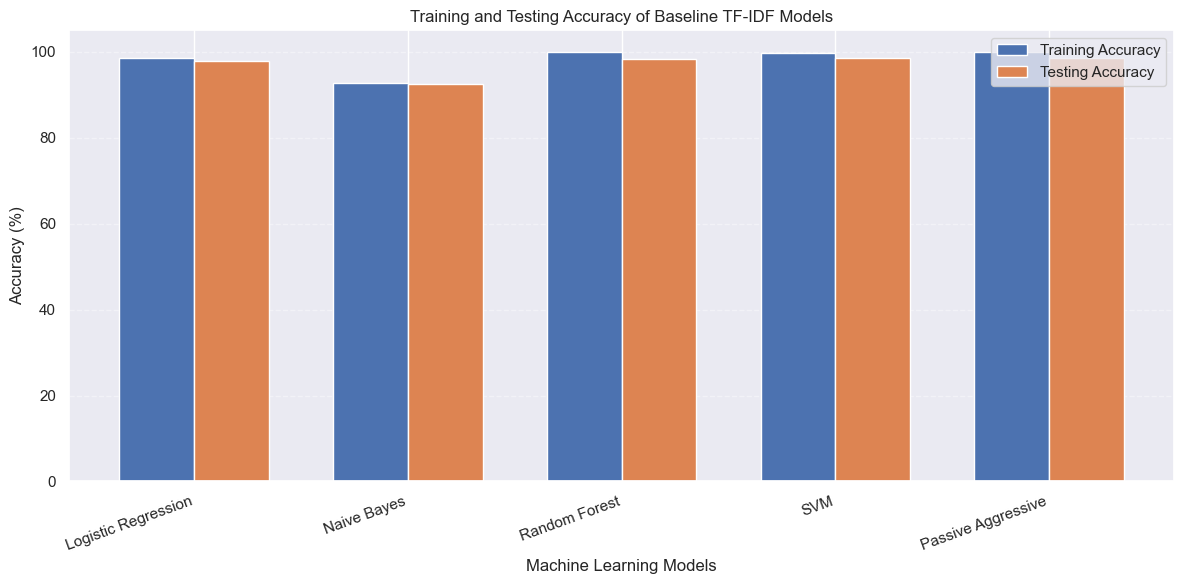

In [12]:
# ============================================================
# STEP 8C: TRAINING VS TESTING ACCURACY
# BASELINE TF-IDF MODELS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Get model names
models = baseline_overfit_df.index

# Get training accuracy
train_accuracy = baseline_overfit_df["Train (%)"].values

# Get testing accuracy
test_accuracy = baseline_overfit_df["Test (%)"].values

# Create positions for the models
x = np.arange(len(models))

# Width of each bar
width = 0.35

# Create figure
plt.figure(figsize=(12, 6))

# Plot training accuracy
plt.bar(
    x - width / 2,
    train_accuracy,
    width,
    label="Training Accuracy"
)

# Plot testing accuracy
plt.bar(
    x + width / 2,
    test_accuracy,
    width,
    label="Testing Accuracy"
)

# Add axis labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Training and Testing Accuracy of Baseline TF-IDF Models")

# Set model names on x-axis
plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

# Add legend
plt.legend()

# Add horizontal grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Adjust layout
plt.tight_layout()

# Display figure
plt.show()

In [13]:
# ============================================================
# SAVE BASELINE SVM MODEL
# ============================================================

import joblib
import os

# Create saved_model folder
os.makedirs("saved_model", exist_ok=True)

# Train the SVM again using the SAME methodology
baseline_svm = LinearSVC(max_iter=2000)

baseline_svm.fit(X_train, y_train)

# Save the trained SVM
joblib.dump(
    baseline_svm,
    "saved_model/baseline_svm.pkl"
)

print("Baseline SVM saved successfully!")

Baseline SVM saved successfully!


## STEP 9: Confusion Matrices (Baseline Models) - Figure 4.1

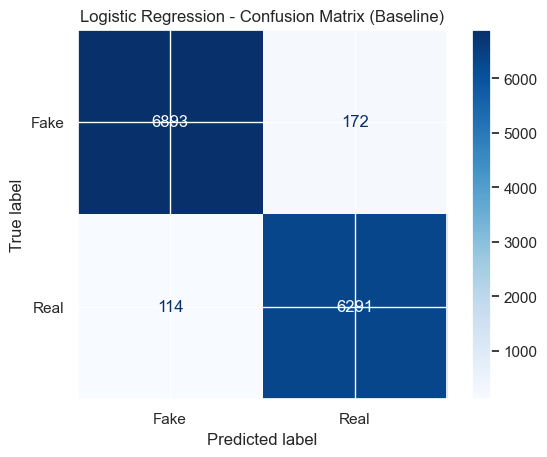

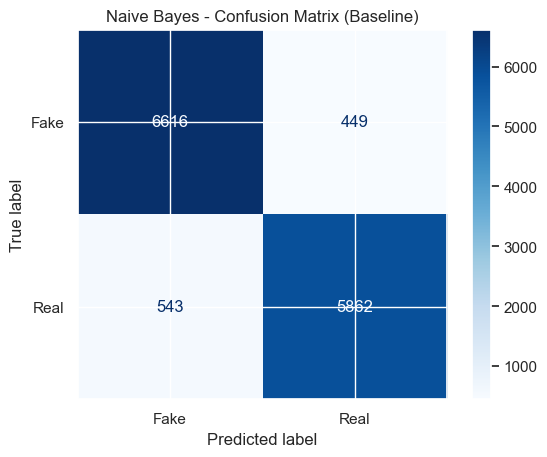

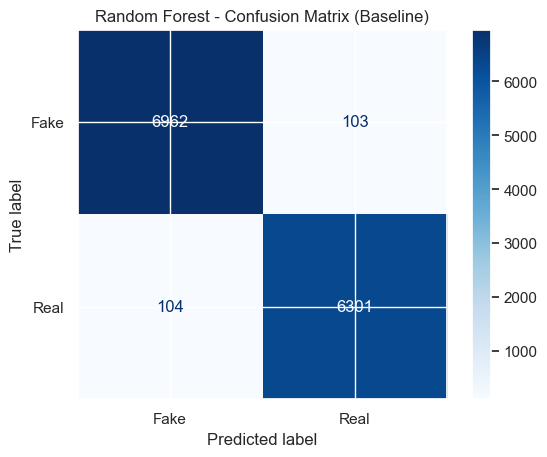

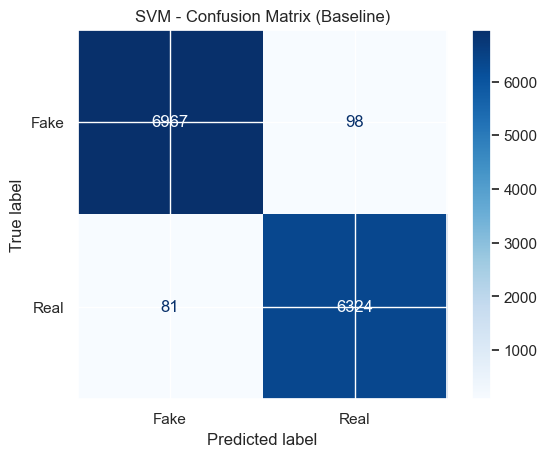

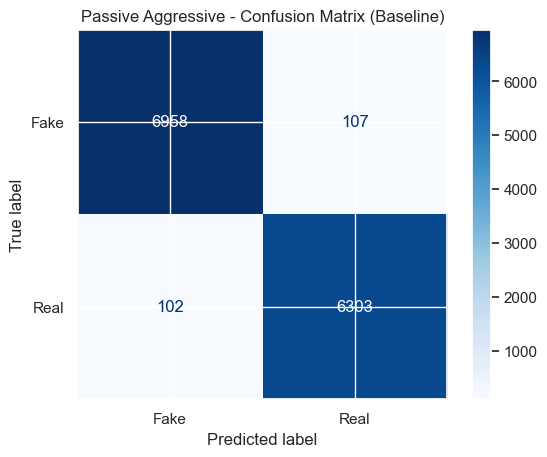

In [14]:
for name, cm in baseline_conf_matrices.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake","Real"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{name} - Confusion Matrix (Baseline)")
    plt.show()

## STEP 10: Baseline Accuracy/F1 Comparison Chart (Figure 4.2)

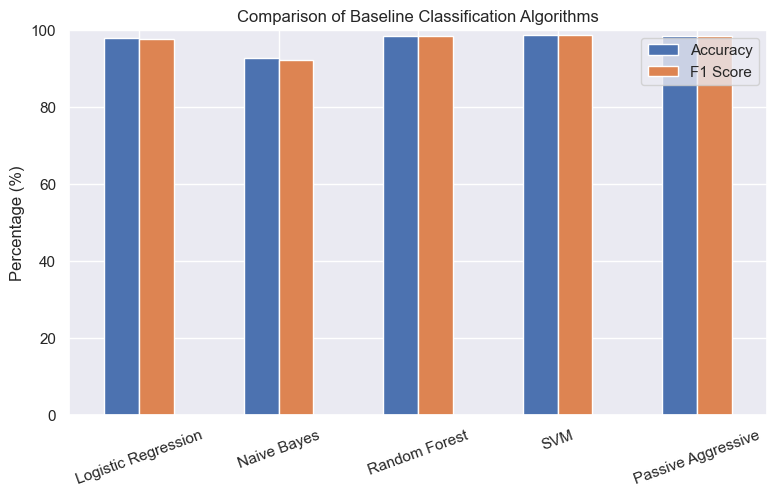

In [15]:
baseline_df[["Accuracy","F1 Score"]].plot(kind="bar", figsize=(9,5))
plt.title("Comparison of Baseline Classification Algorithms")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.ylim(0,100)
plt.show()

---
# ANALYSIS 2: FEATURE FUSION (TF-IDF + Stylometric Features)
This is the first half of the proposed novel method: adding hand-engineered writing-style features on top of TF-IDF word features.

## STEP 11: Extract Stylometric Features
Measures HOW an article is written (length, punctuation, capitalization), not just WHAT words it uses. Computed from the debiased original text, since cleaning already removed the punctuation/capitalization we need here.

In [16]:
def stylometric_features(text):
    text = str(text)
    char_count = len(text)
    words = text.split()
    word_count = len(words)
    exclaim_count = text.count("!")
    question_count = text.count("?")
    capital_ratio = sum(1 for c in text if c.isupper()) / (char_count + 1)
    avg_word_length = char_count / (word_count + 1)
    return pd.Series({
        "char_count": char_count, "word_count": word_count,
        "exclaim_count": exclaim_count, "question_count": question_count,
        "capital_ratio": capital_ratio, "avg_word_length": avg_word_length,
    })

print("Extracting stylometric features (this may take a minute)...")
style_features = df["content_debiased"].apply(stylometric_features)
style_features.describe()

Extracting stylometric features (this may take a minute)...


,char_count,word_count,exclaim_count,question_count,capital_ratio,avg_word_length
count,44898.000000,44898.000000,44898.000000,44898.000000,44898.000000,44898.000000
mean,2530.371241,414.756470,0.488374,0.720500,0.054873,6.104664
std,2174.274961,351.781212,1.528085,1.831436,0.058434,0.899914
min,31.000000,2.000000,0.000000,0.000000,0.000000,4.625000
25%,1300.250000,213.000000,0.000000,0.000000,0.032335,5.884434
50%,2252.000000,372.000000,0.000000,0.000000,0.040486,6.087277
75%,3172.000000,523.000000,0.000000,1.000000,0.054187,6.282192
max,51893.000000,8148.000000,133.000000,94.000000,0.844262,99.666667


### Understanding the `.describe()` Output
- **count** - how many articles were measured
- **mean** - the average value
- **std** (standard deviation) - how spread out values are around the mean (NOT the same as median - std measures spread, median measures the middle value)
- **min** - the smallest value found
- **25% / 50% / 75%** - the value below which that percentage of articles fall (50% is the median - the true middle value when sorted)
- **max** - the largest value found

## STEP 12: Scale Stylometric Features and Fuse with TF-IDF
The 6 stylometric features are on very different scales than TF-IDF (e.g. word_count might be 500, while a TF-IDF score is usually under 1). They are scaled to 0-1, then joined side by side with the 5,000 TF-IDF features.

**Result: 5,006 total features per article** - 5,000 word-content (TF-IDF) features + 6 stylometric (writing-style) features. This gives the model two independent types of evidence, which is what makes fusion more informative than TF-IDF alone. (Note: these are called *stylometric*, not *semantic* - true semantic meaning would require word embeddings like SBERT, noted as future work.)

In [17]:
scaler = MinMaxScaler()
style_scaled = scaler.fit_transform(style_features)

X_fused = hstack([X, csr_matrix(style_scaled)])
print("Fused feature matrix shape:", X_fused.shape)
print("(5000 TF-IDF word features + 6 stylometric style features = 5006 total)")

Fused feature matrix shape: (44898, 5006)
(5000 TF-IDF word features + 6 stylometric style features = 5006 total)


## STEP 13: Train/Test Split on Fused Features

In [18]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fused, y, test_size=0.3, random_state=42, shuffle=True
)
print("Fused Train shape:", X_train_f.shape, " Fused Test shape:", X_test_f.shape)

Fused Train shape: (31428, 5006)  Fused Test shape: (13470, 5006)


## STEP 14: Train 5 Models on Fused Features
Same 5 algorithms as Analysis 1, retrained on the richer fused feature set, to see whether adding stylometric features improves each model.

In [19]:
fused_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": LinearSVC(max_iter=2000),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
}

fused_results = {}
for name, model in fused_models.items():
    print(f"Training {name} on fused features...")
    model.fit(X_train_f, y_train_f)
    preds = model.predict(X_test_f)
    acc = accuracy_score(y_test_f, preds) * 100
    f1 = f1_score(y_test_f, preds) * 100
    prec = precision_score(y_test_f, preds) * 100
    rec = recall_score(y_test_f, preds) * 100
    fused_results[name] = {"Accuracy": acc, "F1 Score": f1, "Precision": prec, "Recall": rec}
    print(f"  {name} -> Accuracy: {acc:.2f}%  F1: {f1:.2f}%  Precision: {prec:.2f}%  Recall: {rec:.2f}%")

fused_results_df = pd.DataFrame(fused_results).T.round(2)
print("\n=== RESULTS ON FUSED FEATURES (Table 4.2) ===")
fused_results_df

Training Logistic Regression on fused features...
  Logistic Regression -> Accuracy: 98.32%  F1: 98.24%  Precision: 97.79%  Recall: 98.70%
Training Naive Bayes on fused features...
  Naive Bayes -> Accuracy: 92.70%  F1: 92.28%  Precision: 92.88%  Recall: 91.68%
Training Random Forest on fused features...
  Random Forest -> Accuracy: 98.89%  F1: 98.84%  Precision: 98.91%  Recall: 98.77%
Training SVM on fused features...
  SVM -> Accuracy: 99.04%  F1: 98.99%  Precision: 98.80%  Recall: 99.19%
Training Passive Aggressive on fused features...
  Passive Aggressive -> Accuracy: 98.82%  F1: 98.76%  Precision: 98.66%  Recall: 98.86%

=== RESULTS ON FUSED FEATURES (Table 4.2) ===


,Accuracy,F1 Score,Precision,Recall
Logistic Regression,98.32,98.24,97.79,98.70
Naive Bayes,92.70,92.28,92.88,91.68
Random Forest,98.89,98.84,98.91,98.77
SVM,99.04,98.99,98.80,99.19
Passive Aggressive,98.82,98.76,98.66,98.86


### STEP 14a: Cross-Validation & Overfitting Check - Fused Features
Checks whether the fused-feature improvement over baseline is reliable and stable.

In [20]:
cv_models_fused = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3),
    "Passive Aggressive": CalibratedClassifierCV(
        PassiveAggressiveClassifier(max_iter=1000, random_state=42), cv=3
    ),
}

print("=== Cross-Validation: FUSED FEATURES ===")
cv_results_fused = {}
for name, model in cv_models_fused.items():
    scores = cross_val_score(model, X_fused, y, cv=cv, scoring="accuracy")
    cv_results_fused[name] = {"CV Mean Acc (%)": round(scores.mean()*100,2),
                               "CV Std (%)": round(scores.std()*100,2)}
    print(f"  {name}: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

print("\n=== Overfitting/Underfitting Check: FUSED FEATURES ===")
fit_results_fused = {}
for name, model in cv_models_fused.items():
    model.fit(X_train_f, y_train_f)
    train_acc = accuracy_score(y_train_f, model.predict(X_train_f)) * 100
    test_acc = accuracy_score(y_test_f, model.predict(X_test_f)) * 100
    gap = round(train_acc - test_acc, 2)
    if gap > 5:
        verdict = "Possible OVERFITTING"
    elif train_acc < 80 and test_acc < 80:
        verdict = "Possible UNDERFITTING"
    else:
        verdict = "Good fit"
    fit_results_fused[name] = {"Train (%)": round(train_acc,2), "Test (%)": round(test_acc,2),
                                "Gap (%)": gap, "Verdict": verdict}
    print(f"  {name}: Train={train_acc:.2f}% Test={test_acc:.2f}% Gap={gap}% -> {verdict}")

=== Cross-Validation: FUSED FEATURES ===
  Logistic Regression: 98.31% (+/- 0.07%)
  Naive Bayes: 92.72% (+/- 0.14%)
  Random Forest: 98.93% (+/- 0.15%)
  SVM: 99.05% (+/- 0.06%)
  Passive Aggressive: 98.99% (+/- 0.07%)

=== Overfitting/Underfitting Check: FUSED FEATURES ===
  Logistic Regression: Train=98.93% Test=98.32% Gap=0.61% -> Good fit
  Naive Bayes: Train=92.98% Test=92.70% Gap=0.28% -> Good fit
  Random Forest: Train=100.00% Test=98.89% Gap=1.11% -> Good fit
  SVM: Train=99.76% Test=98.97% Gap=0.79% -> Good fit
  Passive Aggressive: Train=100.00% Test=98.96% Gap=1.04% -> Good fit


## STEP 14B: Confusion Matrix - Fused Features (SVM)

The confusion matrix is used to evaluate the classification performance of the SVM model using the fused feature representation, which combines TF-IDF features with stylometric features.

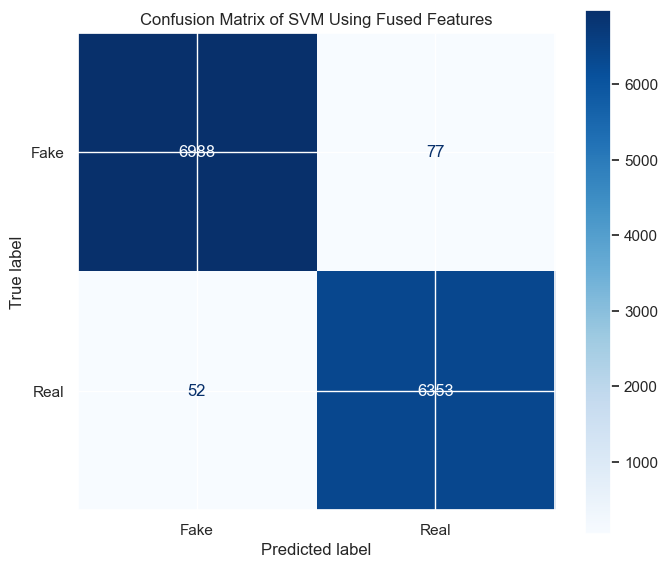

In [21]:
# ============================================================
# STEP 14B: CONFUSION MATRIX
# FUSED FEATURES - SVM
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create SVM model
svm_fused_cm = LinearSVC(random_state=42)

# Train SVM on fused training features
svm_fused_cm.fit(X_train_f, y_train_f)

# Predict on fused test features
svm_fused_preds = svm_fused_cm.predict(X_test_f)

# Generate confusion matrix
cm_svm_fused = confusion_matrix(
    y_test_f,
    svm_fused_preds
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_fused,
    display_labels=["Fake", "Real"]
)

# Create figure
fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

# Add title
ax.set_title("Confusion Matrix of SVM Using Fused Features")

plt.tight_layout()
plt.show()

## STEP 14C: Display Overfitting Results

The training and testing accuracy of the fused-feature models are presented below to compare their performance on training and unseen testing data.

The train-test accuracy gap is also considered to identify possible differences in generalization performance among the models.

In [22]:
# ============================================================
# STEP 14C: DISPLAY OVERFITTING RESULTS
# ============================================================

# Convert the existing overfitting results into a DataFrame
overfit_fused_df = pd.DataFrame(fit_results_fused).T

# Display the results
display(overfit_fused_df)

,Train (%),Test (%),Gap (%),Verdict
Logistic Regression,98.93,98.32,0.61,Good fit
Naive Bayes,92.98,92.7,0.28,Good fit
Random Forest,100.0,98.89,1.11,Good fit
SVM,99.76,98.97,0.79,Good fit
Passive Aggressive,100.0,98.96,1.04,Good fit


## STEP 14D: Training vs Testing Accuracy of Fused-Feature Models

The following figure compares the training and testing accuracy of the machine learning models using fused features.

A relatively small difference between training and testing accuracy indicates consistent performance between training and unseen testing data.

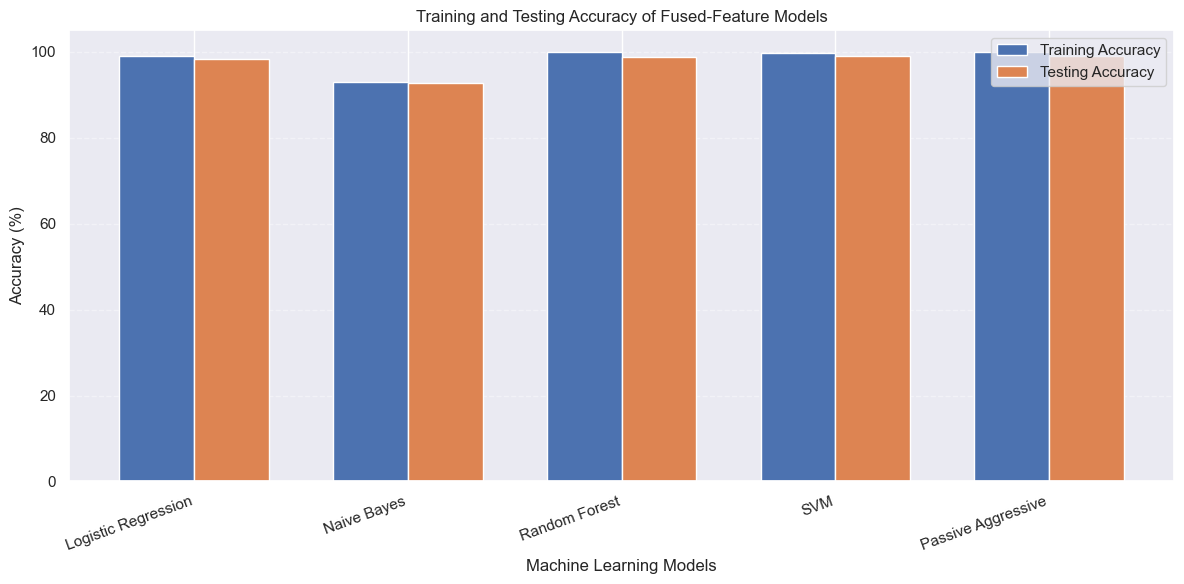

In [23]:
# ============================================================
# STEP 14D: TRAINING VS TESTING ACCURACY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Get model names
models = overfit_fused_df.index

# Get training and testing accuracy
train_accuracy = overfit_fused_df["Train (%)"].values
test_accuracy = overfit_fused_df["Test (%)"].values

# Positions of models
x = np.arange(len(models))

# Width of each bar
width = 0.35

# Create figure
plt.figure(figsize=(12, 6))

# Training accuracy
plt.bar(
    x - width/2,
    train_accuracy,
    width,
    label="Training Accuracy"
)

# Testing accuracy
plt.bar(
    x + width/2,
    test_accuracy,
    width,
    label="Testing Accuracy"
)

# Labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Training and Testing Accuracy of Fused-Feature Models")

# Model names
plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

# Legend
plt.legend()

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

---
# ANALYSIS 3: PROPOSED WEIGHTED VOTING ENSEMBLE
The second half of the proposed novel method: combining the top 3 performing models (automatically selected, not hardcoded) into one weighted-vote team.

## STEP 15: Build the Weighted Voting Ensemble
Automatically finds whichever 3 models scored highest on F1 in Step 14, and combines exactly those into the ensemble - this ensures the ensemble always uses the actual best performers, regardless of dataset or how rankings shift between runs. Each model's vote is weighted by its own F1-score.

In [24]:
model_lookup = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": LinearSVC(max_iter=2000),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
}

# automatically find whichever 3 models scored highest on F1 (no hardcoded names)
top_3_names = (
    pd.Series({name: fused_results[name]["F1 Score"] for name in fused_results})
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
print("Top 3 models selected for this run:", top_3_names)

f1_scores = {name: fused_results[name]["F1 Score"] for name in top_3_names}
total = sum(f1_scores.values())
weights = [round(f1_scores[name] / total, 3) for name in top_3_names]
print("Ensemble weights:", dict(zip(top_3_names, weights)))

estimators = [(name, model_lookup[name]) for name in top_3_names]
ensemble = VotingClassifier(estimators=estimators, voting="hard", weights=weights)

print("\nTraining the proposed weighted voting ensemble...")
ensemble.fit(X_train_f, y_train_f)
ensemble_preds = ensemble.predict(X_test_f)

ens_acc = accuracy_score(y_test_f, ensemble_preds) * 100
ens_f1 = f1_score(y_test_f, ensemble_preds) * 100
ens_prec = precision_score(y_test_f, ensemble_preds) * 100
ens_rec = recall_score(y_test_f, ensemble_preds) * 100

print(f"\n=== PROPOSED ENSEMBLE RESULT ===")
print(f"Accuracy: {ens_acc:.2f}%  F1: {ens_f1:.2f}%  Precision: {ens_prec:.2f}%  Recall: {ens_rec:.2f}%")

Top 3 models selected for this run: ['SVM', 'Random Forest', 'Passive Aggressive']
Ensemble weights: {'SVM': 0.334, 'Random Forest': 0.333, 'Passive Aggressive': 0.333}

Training the proposed weighted voting ensemble...

=== PROPOSED ENSEMBLE RESULT ===
Accuracy: 99.08%  F1: 99.03%  Precision: 98.93%  Recall: 99.14%


## STEP 15A: Confusion Matrix - Proposed Weighted Voting Ensemble

The confusion matrix is used to examine the classification performance of the proposed weighted voting ensemble on the test dataset. It shows the number of correctly and incorrectly classified fake and real news articles.

<Figure size 700x600 with 0 Axes>

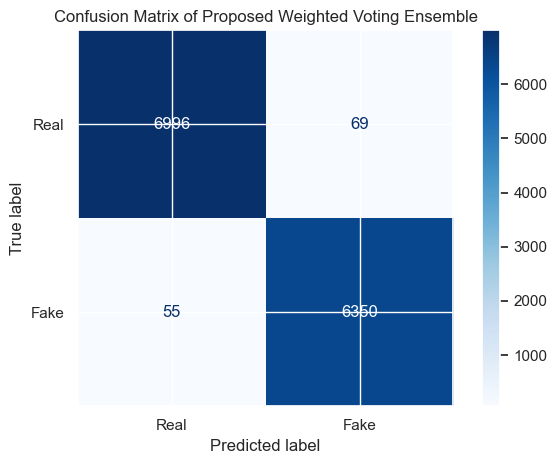

In [25]:
# ============================================================
# STEP 15A: CONFUSION MATRIX
# PROPOSED WEIGHTED VOTING ENSEMBLE
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix using the existing ensemble predictions
cm_ensemble = confusion_matrix(
    y_test_f,
    ensemble_preds
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ensemble,
    display_labels=["Real", "Fake"]
)

# Create figure
plt.figure(figsize=(7, 6))

disp.plot(
    cmap="Blues",
    values_format="d"
)

# Add title
plt.title("Confusion Matrix of Proposed Weighted Voting Ensemble")

# Adjust layout
plt.tight_layout()

# Display
plt.show()

## STEP 16: Final Comparison Table - All Models vs Proposed Ensemble (Table 4.3)

In [26]:
fused_results["Proposed Ensemble"] = {
    "Accuracy": ens_acc, "F1 Score": ens_f1, "Precision": ens_prec, "Recall": ens_rec
}
final_df = pd.DataFrame(fused_results).T.round(2)
print("=== FINAL COMPARISON: 5 Individual Models vs Proposed Ensemble ===")
final_df

=== FINAL COMPARISON: 5 Individual Models vs Proposed Ensemble ===


,Accuracy,F1 Score,Precision,Recall
Logistic Regression,98.32,98.24,97.79,98.70
Naive Bayes,92.70,92.28,92.88,91.68
Random Forest,98.89,98.84,98.91,98.77
SVM,99.04,98.99,98.80,99.19
Passive Aggressive,98.82,98.76,98.66,98.86
Proposed Ensemble,99.08,99.03,98.93,99.14


### STEP 16a: Cross-Validation & Overfitting Check - Proposed Ensemble
Checks whether the ensemble's win over individual models is reliable, not a fluke.

In [27]:
ensemble_cv = VotingClassifier(
    estimators=[(name, model_lookup[name]) for name in top_3_names],
    voting="hard",
    weights=weights,
)

print("=== Cross-Validation: PROPOSED ENSEMBLE ===")
ensemble_scores = cross_val_score(ensemble_cv, X_fused, y, cv=cv, scoring="accuracy")
print(f"  Proposed Ensemble: {ensemble_scores.mean()*100:.2f}% (+/- {ensemble_scores.std()*100:.2f}%)")

print("\n=== Overfitting/Underfitting Check: PROPOSED ENSEMBLE ===")
train_acc = accuracy_score(y_train_f, ensemble.predict(X_train_f)) * 100
test_acc = accuracy_score(y_test_f, ensemble_preds) * 100
gap = round(train_acc - test_acc, 2)
if gap > 5:
    verdict = "Possible OVERFITTING"
elif train_acc < 80 and test_acc < 80:
    verdict = "Possible UNDERFITTING"
else:
    verdict = "Good fit"
print(f"  Proposed Ensemble: Train={train_acc:.2f}% Test={test_acc:.2f}% Gap={gap}% -> {verdict}")

=== Cross-Validation: PROPOSED ENSEMBLE ===
  Proposed Ensemble: 99.16% (+/- 0.08%)

=== Overfitting/Underfitting Check: PROPOSED ENSEMBLE ===
  Proposed Ensemble: Train=100.00% Test=99.08% Gap=0.92% -> Good fit


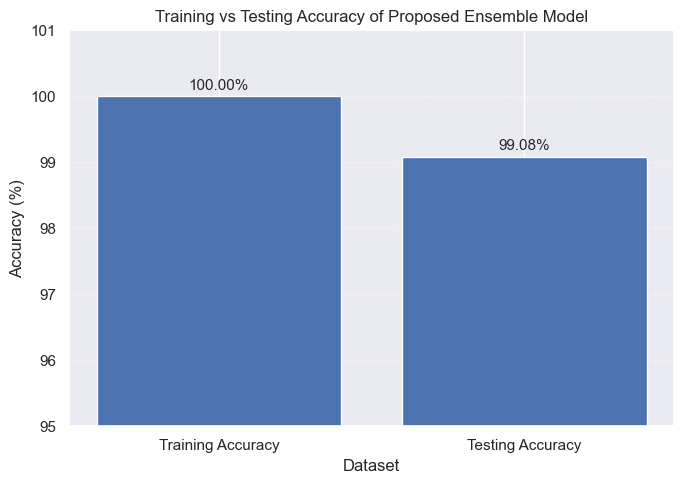

In [28]:
# ============================================================
# OVERFITTING ANALYSIS FIGURE - PROPOSED ENSEMBLE
# ============================================================

import matplotlib.pyplot as plt

# Accuracy values from the existing overfitting analysis
ensemble_train = 100.00
ensemble_test = 99.08

# Create figure
plt.figure(figsize=(7, 5))

# Create bars
bars = plt.bar(
    ["Training Accuracy", "Testing Accuracy"],
    [ensemble_train, ensemble_test]
)

# Add values above bars
for bar, value in zip(bars, [ensemble_train, ensemble_test]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

# Labels and title
plt.ylabel("Accuracy (%)")
plt.xlabel("Dataset")
plt.title("Training vs Testing Accuracy of Proposed Ensemble Model")

# Set y-axis
plt.ylim(95, 101)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 17: Comparison Chart - Baseline vs Fused vs Ensemble (Figure 4.3)

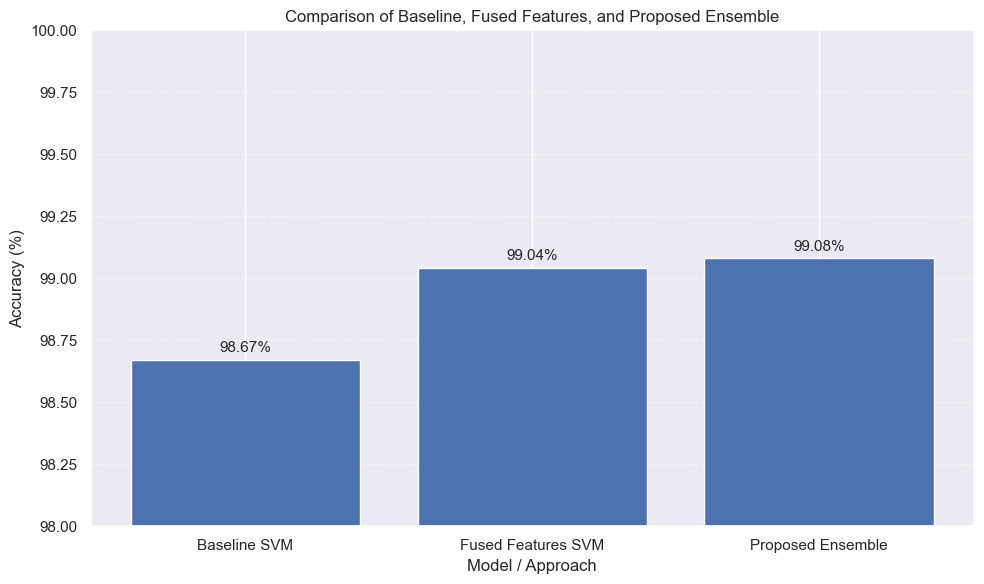

In [29]:
# ============================================================
# STEP 17: COMPARISON CHART
# BASELINE vs FUSED FEATURES vs PROPOSED ENSEMBLE
# ============================================================

import matplotlib.pyplot as plt

# Accuracy values obtained from the experimental results
methods = [
    "Baseline SVM",
    "Fused Features SVM",
    "Proposed Ensemble"
]

accuracy = [
    98.67,
    99.04,
    99.08
]

# Create figure
plt.figure(figsize=(10, 6))

# Create bar chart
bars = plt.bar(
    methods,
    accuracy
)

# Add accuracy values above each bar
for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Add labels and title
plt.xlabel("Model / Approach")
plt.ylabel("Accuracy (%)")

plt.title(
    "Comparison of Baseline, Fused Features, and Proposed Ensemble"
)

# Set y-axis range for clearer comparison
plt.ylim(98, 100)

# Add horizontal grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

In [30]:
# ============================================================
# SAVE THE FIVE INDIVIDUAL FUSED MODELS
# ============================================================

import joblib
import os

os.makedirs("saved_model", exist_ok=True)

joblib.dump(
    fused_models,
    "saved_model/fused_models.pkl"
)

print("fused_models.pkl saved successfully!")

fused_models.pkl saved successfully!


## STEP 18: Error Metrics (Log Loss, Brier Score, MSE, RMSE)

MSE/RMSE are built for predicting numbers, not categories - since our problem is 
Fake/Real classification, we compute them on the model's predicted PROBABILITY 
(e.g. "80% sure it's fake") versus the actual 0/1 answer. This measures not just 
whether predictions were right, but how confidently correct they were.

In [31]:
# LinearSVC and PassiveAggressiveClassifier don't give probability scores natively,
# so we wrap them with CalibratedClassifierCV to enable Log Loss/Brier Score
error_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3),
    "Passive Aggressive": CalibratedClassifierCV(
        PassiveAggressiveClassifier(max_iter=1000, random_state=42), cv=3
    ),
}

error_results = {}

for name, model in error_models.items():
    # train each model fresh on the fused training data
    model.fit(X_train_f, y_train_f)

    # get the predicted PROBABILITY of being class 1 (Real), not just the final label
    probs = model.predict_proba(X_test_f)[:, 1]

    # Log Loss: penalizes confident WRONG predictions heavily, rewards confident correct ones
    ll = log_loss(y_test_f, probs)

    # Brier Score: average squared difference between predicted probability and actual answer
    brier = brier_score_loss(y_test_f, probs)

    # MSE: same idea as Brier Score, computed directly on probabilities vs actual 0/1 labels
    mse = mean_squared_error(y_test_f, probs)

    # RMSE: square root of MSE, puts the error back into an easier-to-read scale
    rmse = np.sqrt(mse)

    error_results[name] = {"Log Loss": round(ll,4), "Brier Score": round(brier,4),
                            "MSE": round(mse,4), "RMSE": round(rmse,4)}

    print(f"{name}: Log Loss={ll:.4f}  Brier={brier:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}")

# display all 5 models' error metrics together as one final table
error_df = pd.DataFrame(error_results).T
print("\n=== FINAL ERROR METRICS TABLE (Table 4.4) ===")
error_df

Logistic Regression: Log Loss=0.0850  Brier=0.0179  MSE=0.0179  RMSE=0.1340
Naive Bayes: Log Loss=0.1911  Brier=0.0553  MSE=0.0553  RMSE=0.2352
Random Forest: Log Loss=0.1415  Brier=0.0273  MSE=0.0273  RMSE=0.1651
SVM: Log Loss=0.0350  Brier=0.0085  MSE=0.0085  RMSE=0.0919
Passive Aggressive: Log Loss=0.0376  Brier=0.0091  MSE=0.0091  RMSE=0.0952

=== FINAL ERROR METRICS TABLE (Table 4.4) ===


,Log Loss,Brier Score,MSE,RMSE
Logistic Regression,0.0850,0.0179,0.0179,0.1340
Naive Bayes,0.1911,0.0553,0.0553,0.2352
Random Forest,0.1415,0.0273,0.0273,0.1651
SVM,0.0350,0.0085,0.0085,0.0919
Passive Aggressive,0.0376,0.0091,0.0091,0.0952


## STEP 19: Save Trained Model for Streamlit Application

The trained TF-IDF vectorizer, stylometric scaler, and proposed ensemble model are saved for later use in the Streamlit application.

In [32]:
# ============================================================
# STEP 18: SAVE TRAINED MODEL
# ============================================================

import joblib
import os

# Create a folder for the saved model
os.makedirs("saved_model", exist_ok=True)

# ------------------------------------------------------------
# Save TF-IDF Vectorizer
# ------------------------------------------------------------

joblib.dump(
    tfidf,
    "saved_model/tfidf_vectorizer.pkl"
)

# ------------------------------------------------------------
# Save Stylometric Feature Scaler
# ------------------------------------------------------------

joblib.dump(
    scaler,
    "saved_model/stylometric_scaler.pkl"
)

# ------------------------------------------------------------
# Save Proposed Ensemble Model
# ------------------------------------------------------------

joblib.dump(
    ensemble,
    "saved_model/proposed_ensemble.pkl"
)

print("==============================================")
print("MODEL SAVING COMPLETED")
print("==============================================")

print("✓ TF-IDF vectorizer saved")
print("✓ Stylometric scaler saved")
print("✓ Proposed ensemble saved")

print("\nSaved files:")
print("1. saved_model/tfidf_vectorizer.pkl")
print("2. saved_model/stylometric_scaler.pkl")
print("3. saved_model/proposed_ensemble.pkl")

MODEL SAVING COMPLETED
✓ TF-IDF vectorizer saved
✓ Stylometric scaler saved
✓ Proposed ensemble saved

Saved files:
1. saved_model/tfidf_vectorizer.pkl
2. saved_model/stylometric_scaler.pkl
3. saved_model/proposed_ensemble.pkl


---
## Thank You!
